# Lab Evaluation 1 - Data Analytics Using Python

## Set 1: HR Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the dataset
np.random.seed(42)
num_employees = 1000
departments = ['Sales', 'HR', 'IT', 'Finance', 'Marketing']

df_employee = pd.DataFrame({
    'Employee_id': range(1, num_employees + 1),
    'Department': np.random.choice(departments, num_employees),
    'Age': np.random.randint(22, 61, num_employees),
    'Hire_date': pd.to_datetime(np.random.choice(pd.date_range('2010-01-01', '2022-12-31'), num_employees)),
    'Salary': np.clip(np.random.normal(60000, 15000, num_employees), 30000, 150000).astype(int),
    'Performance_score': np.random.randint(1, 11, num_employees),
    'Full_time': np.random.choice([True, False], num_employees, p=[0.8, 0.2])
})

df_employee.head()

,Employee_id,Department,Age,Hire_date,Salary,Performance_score,Full_time
0,1,Finance,33,2014-10-02,64901,10,True
1,2,Marketing,57,2014-05-05,84435,2,True
2,3,IT,25,2010-03-08,62420,7,True
3,4,Marketing,26,2018-05-20,54078,2,True
4,5,Marketing,58,2016-08-25,52146,4,False


### 1. What is the average salary of each department? Display and visualize the results.

Average salary by department:
Department
Finance      61449.19
HR           61461.95
IT           60207.12
Marketing    61743.71
Sales        60901.31
Name: Salary, dtype: float64


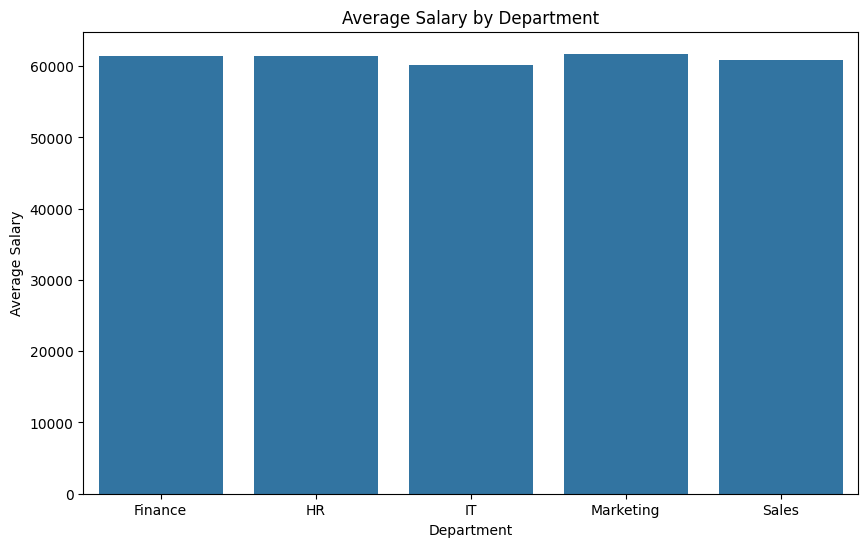

In [2]:
avg_salary_by_dept = df_employee.groupby('Department')['Salary'].mean().round(2)
print('Average salary by department:')
print(avg_salary_by_dept)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_salary_by_dept.index, y=avg_salary_by_dept.values)
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()

### 2. What percentage of full-time and part-time employees works in the company. Display and visualize the results.

Percentage of full-time and part-time employees:
Full_time
True     79.6
False    20.4
Name: proportion, dtype: float64


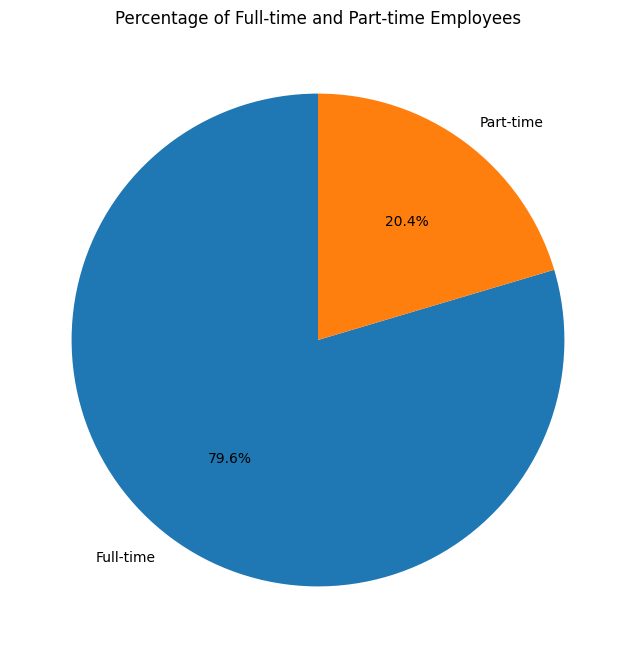

In [3]:
employment_percentage = df_employee['Full_time'].value_counts(normalize=True) * 100
print('Percentage of full-time and part-time employees:')
print(employment_percentage)

plt.figure(figsize=(8, 8))
plt.pie(employment_percentage, labels=['Full-time', 'Part-time'], autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Full-time and Part-time Employees')
plt.show()

### 3. Visualize the distribution of salaries across departments to compare spread and detect potential outliers.

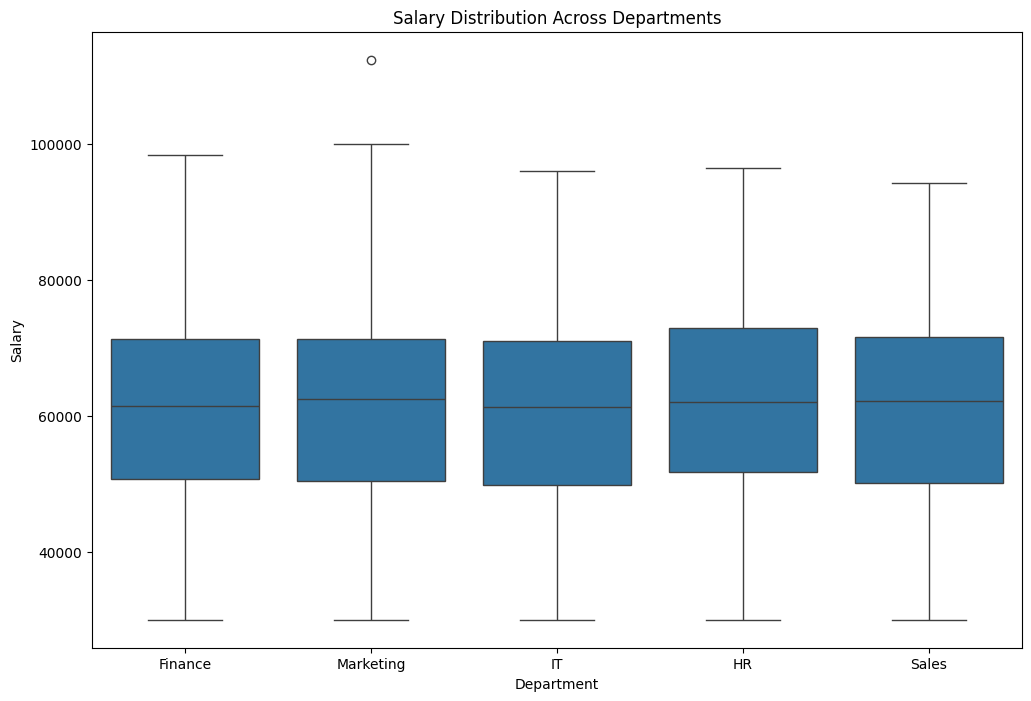

In [4]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Department', y='Salary', data=df_employee)
plt.title('Salary Distribution Across Departments')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.show()

### 4. How many employees were hired each year. Display the result.

Employees hired each year:
Hiring_Year
2010    68
2011    90
2012    71
2013    73
2014    77
2015    93
2016    95
2017    64
2018    77
2019    64
2020    84
2021    71
2022    73
Name: count, dtype: int64


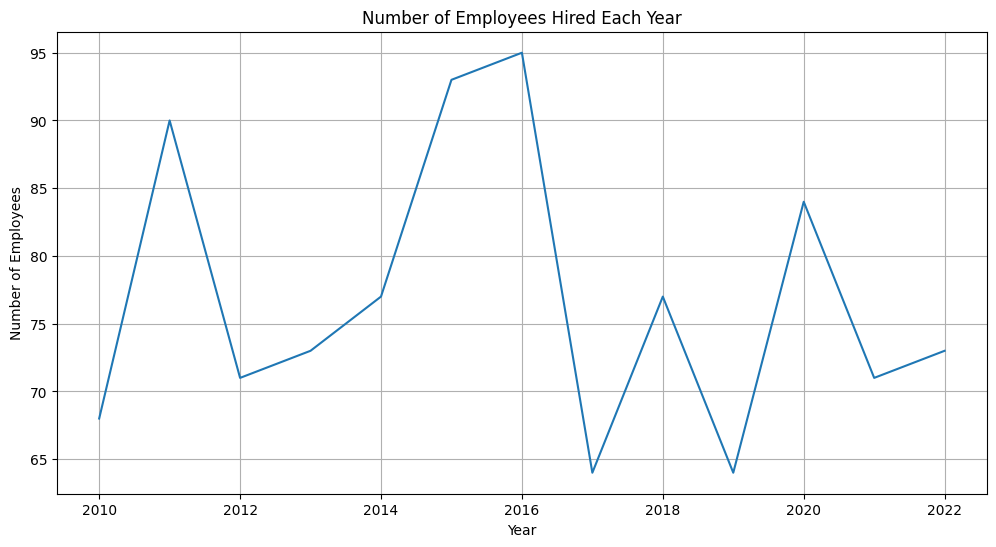

In [5]:
df_employee['Hiring_Year'] = df_employee['Hire_date'].dt.year
hiring_by_year = df_employee['Hiring_Year'].value_counts().sort_index()
print('Employees hired each year:')
print(hiring_by_year)

plt.figure(figsize=(12, 6))
sns.lineplot(x=hiring_by_year.index, y=hiring_by_year.values)
plt.title('Number of Employees Hired Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Employees')
plt.grid(True)
plt.show()

## Set 2: Retail Company Analytics

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the dataset
np.random.seed(42)
num_products = 500
categories = ['Electronics', 'Clothing', 'Groceries', 'Furniture']

df_product = pd.DataFrame({
    'Product_ID': range(1, num_products + 1),
    'Category': np.random.choice(categories, num_products),
    'Price': np.clip(np.random.normal(500, 200, num_products), 100, 2000).astype(int),
    'Quantity_Sold': np.random.randint(10, 501, num_products),
    'Launch_Date': pd.to_datetime(np.random.choice(pd.date_range('2015-01-01', '2023-12-31'), num_products)),
    'Rating': np.random.randint(1, 6, num_products),
    'In_Stock': np.random.choice([True, False], num_products, p=[0.7, 0.3])
})

df_product.head()

,Product_ID,Category,Price,Quantity_Sold,Launch_Date,Rating,In_Stock
0,1,Groceries,330,87,2018-04-08,2,False
1,2,Furniture,197,297,2015-12-22,4,True
2,3,Electronics,410,129,2015-07-10,2,False
3,4,Groceries,671,311,2021-10-05,2,True
4,5,Groceries,542,500,2016-11-30,1,False


### 1. Compute the average price of products per category and display it. Plot the result to compare price distribution across categories.

Average price by category:
Category
Clothing       485.48
Electronics    526.11
Furniture      507.46
Groceries      476.62
Name: Price, dtype: float64


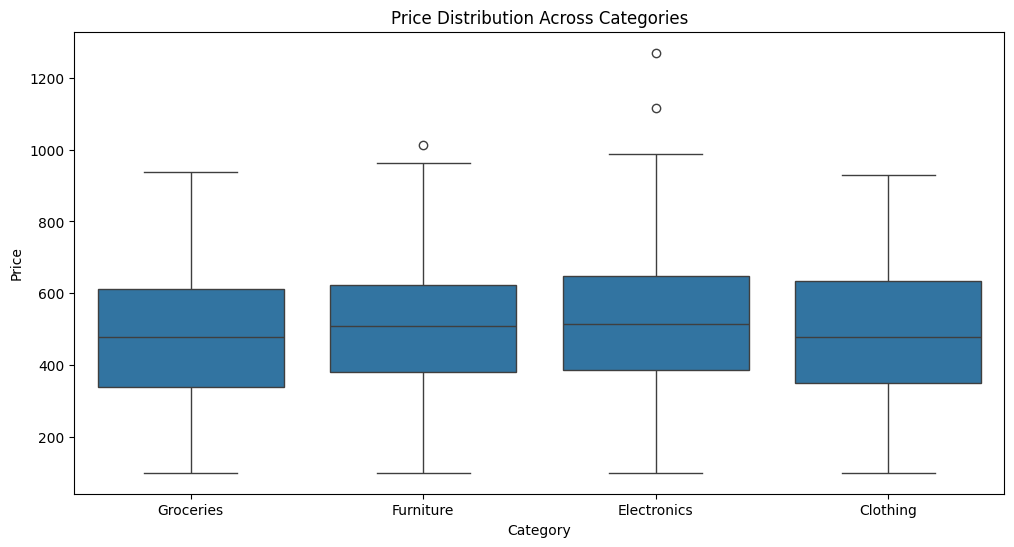

In [7]:
avg_price_by_cat = df_product.groupby('Category')['Price'].mean().round(2)
print('Average price by category:')
print(avg_price_by_cat)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Price', data=df_product)
plt.title('Price Distribution Across Categories')
plt.xlabel('Category')
plt.ylabel('Price')
plt.show()

### 2. Display the total quantity sold per year and visualize it.

Total quantity sold per year:
Launch_Year
2015    12989
2016    15965
2017    15206
2018    16699
2019    10197
2020    15271
2021    13816
2022    11829
2023    14809
Name: Quantity_Sold, dtype: int32


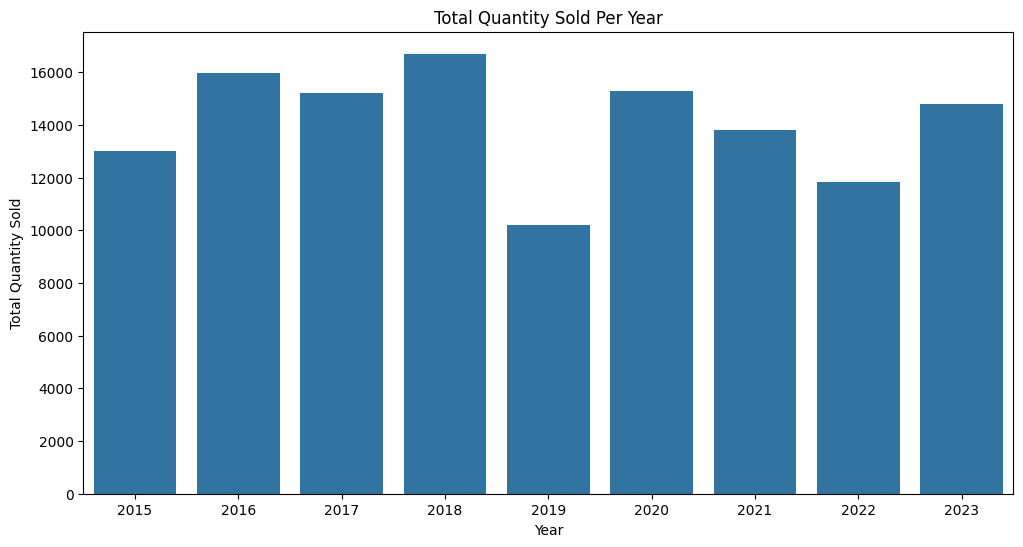

In [8]:
df_product['Launch_Year'] = df_product['Launch_Date'].dt.year
quantity_by_year = df_product.groupby('Launch_Year')['Quantity_Sold'].sum()
print('Total quantity sold per year:')
print(quantity_by_year)

plt.figure(figsize=(12, 6))
sns.barplot(x=quantity_by_year.index, y=quantity_by_year.values)
plt.title('Total Quantity Sold Per Year')
plt.xlabel('Year')
plt.ylabel('Total Quantity Sold')
plt.show()

### 3. Display the relationship between product Price, Quantity_Sold, and Rating. Visualize the result with appropriate plot. Interpret the strongest relationship observed.

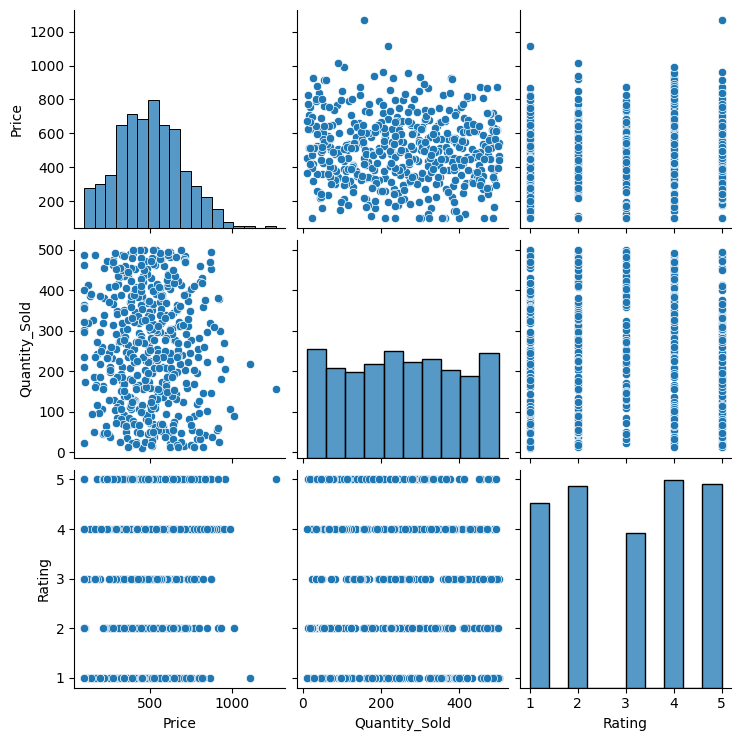

Correlation matrix:
                  Price  Quantity_Sold    Rating
Price          1.000000      -0.052050  0.035763
Quantity_Sold -0.052050       1.000000 -0.088938
Rating         0.035763      -0.088938  1.000000


In [9]:
sns.pairplot(df_product[['Price', 'Quantity_Sold', 'Rating']])
plt.show()

print('Correlation matrix:')
print(df_product[['Price', 'Quantity_Sold', 'Rating']].corr())

**Interpretation:** The pair plot and the correlation matrix show a very weak correlation between Price, Quantity_Sold, and Rating. This is expected as the data is generated randomly. In a real-world scenario, we might expect to see a negative correlation between Price and Quantity_Sold (higher price, lower quantity sold).

### 4. Identify the year with maximum total sales revenue (Price * Quantity_Sold). Display the result.

In [10]:
df_product['Revenue'] = df_product['Price'] * df_product['Quantity_Sold']
revenue_by_year = df_product.groupby('Launch_Year')['Revenue'].sum()
max_revenue_year = revenue_by_year.idxmax()
print(f'The year with the maximum total sales revenue is: {max_revenue_year}')

The year with the maximum total sales revenue is: 2016


## Set 3: Restaurant Analytics

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the dataset
np.random.seed(42)
num_groups = 200
food_categories = ['Starters', 'Main Course', 'Desserts', 'Beverages']
payment_modes = ['Cash', 'Card', 'UPI', 'Wallet']

df_restaurant = pd.DataFrame({
    'Group_ID': range(1, num_groups + 1),
    'Group_Size': np.random.randint(1, 7, num_groups),
    'Food_Category': np.random.choice(food_categories, num_groups),
    'Bill_Amount': np.random.uniform(100, 600, num_groups).astype(int),
    'Visit_Date': pd.to_datetime(np.random.choice(pd.date_range('2023-08-01', '2023-08-31'), num_groups)),
    'Payment_Mode': np.random.choice(payment_modes, num_groups, p=[0.1, 0.2, 0.5, 0.2]),
    'Rating': np.random.randint(1, 6, num_groups),
    'Promotional_Offer': np.random.choice([True, False], num_groups, p=[0.3, 0.7])
})

df_restaurant.head()

,Group_ID,Group_Size,Food_Category,Bill_Amount,Visit_Date,Payment_Mode,Rating,Promotional_Offer
0,1,4,Beverages,349,2023-08-08,UPI,3,False
1,2,5,Beverages,386,2023-08-10,Card,5,True
2,3,3,Beverages,484,2023-08-09,Wallet,1,False
3,4,5,Starters,121,2023-08-18,UPI,1,False
4,5,5,Beverages,597,2023-08-27,Card,1,True


### 1. Which days of the week bring in the most revenue? Visualize the results.

Revenue by day of the week:
Day_of_Week
Monday        9957
Tuesday      11345
Wednesday     8355
Thursday     11943
Friday        7206
Saturday     10533
Sunday       10044
Name: Bill_Amount, dtype: int64


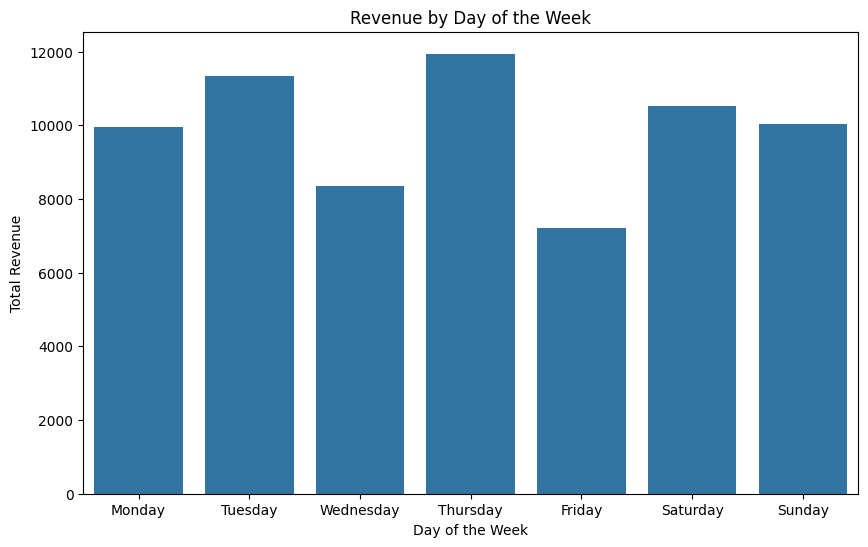

In [12]:
df_restaurant['Day_of_Week'] = df_restaurant['Visit_Date'].dt.day_name()
revenue_by_day = df_restaurant.groupby('Day_of_Week')['Bill_Amount'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print('Revenue by day of the week:')
print(revenue_by_day)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values)
plt.title('Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue')
plt.show()

### 2. Identify and display popular food categories across different group sizes? Visualize the results.

Popular food categories by group size:
Food_Category  Beverages  Desserts  Main Course  Starters
Group_Size                                               
1                     10        10            7         6
2                      9         7            7         6
3                     11         5            7         9
4                     11         8           11        12
5                     14         9            5         4
6                     11         5            6        10


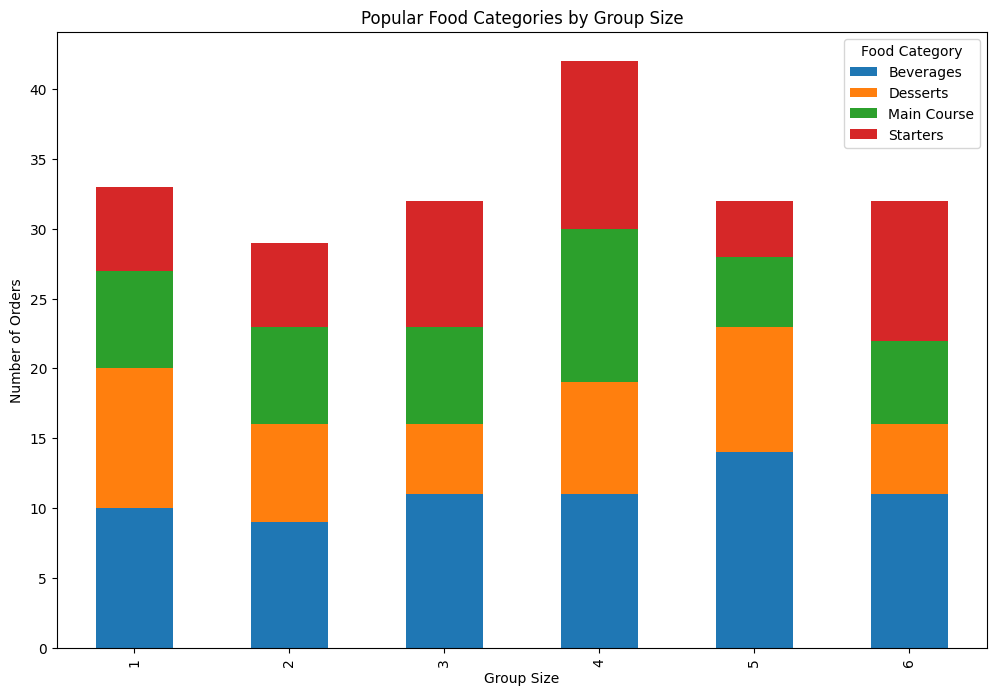

In [13]:
popular_categories = pd.crosstab(df_restaurant['Group_Size'], df_restaurant['Food_Category'])
print('Popular food categories by group size:')
print(popular_categories)

popular_categories.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Popular Food Categories by Group Size')
plt.xlabel('Group Size')
plt.ylabel('Number of Orders')
plt.legend(title='Food Category')
plt.show()

### 3. Identify and display Customer satisfaction trends with and without offers. Visualize the results.

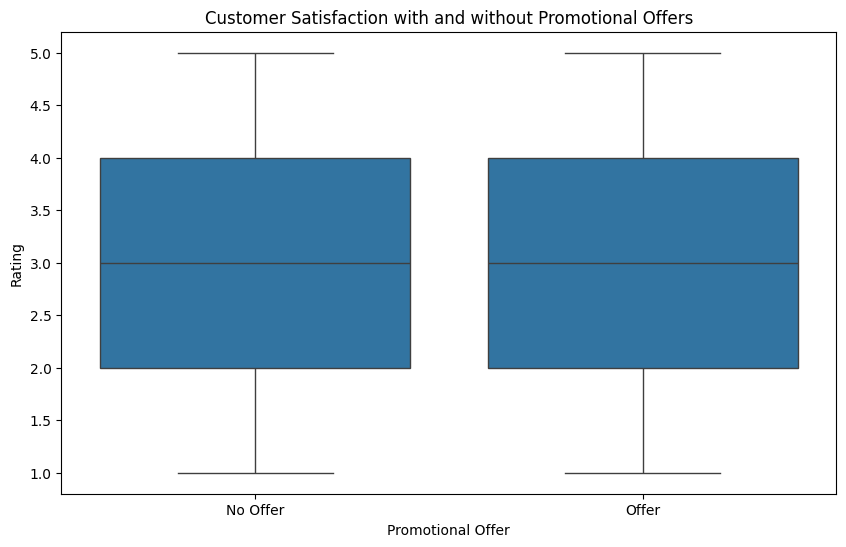

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Promotional_Offer', y='Rating', data=df_restaurant)
plt.title('Customer Satisfaction with and without Promotional Offers')
plt.xlabel('Promotional Offer')
plt.ylabel('Rating')
plt.xticks([0, 1], ['No Offer', 'Offer'])
plt.show()

### 4. Find the revenue share by payment mode. Visualize the results.

Revenue share by payment mode:
Payment_Mode
Card      19596
Cash       4665
UPI       34777
Wallet    10345
Name: Bill_Amount, dtype: int64


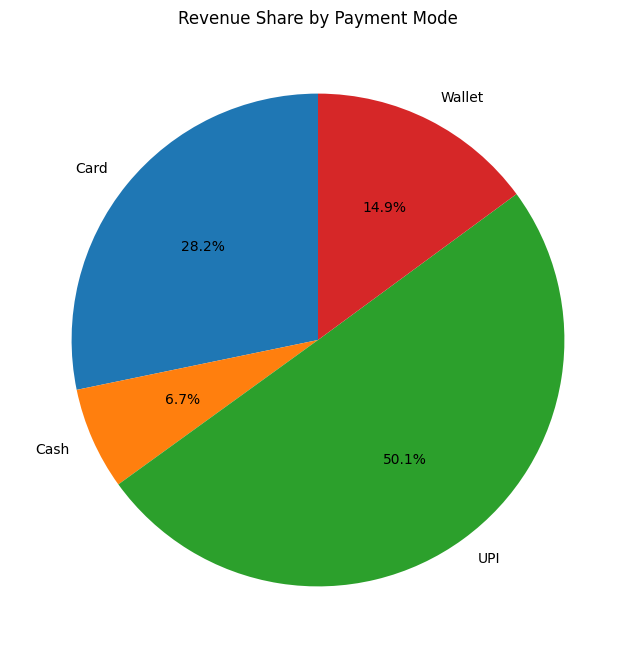

In [15]:
revenue_by_payment = df_restaurant.groupby('Payment_Mode')['Bill_Amount'].sum()
print('Revenue share by payment mode:')
print(revenue_by_payment)

plt.figure(figsize=(8, 8))
plt.pie(revenue_by_payment, labels=revenue_by_payment.index, autopct='%1.1f%%', startangle=90)
plt.title('Revenue Share by Payment Mode')
plt.show()

## Set 4: Hospital Analytics

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the dataset
np.random.seed(42)
num_patients = 1000
departments = ['Cardiology', 'Orthopedics', 'Neurology', 'General Medicine']
genders = ['Male', 'Female']

df_hospital = pd.DataFrame({
    'Patient_ID': range(1, num_patients + 1),
    'Age': np.random.randint(5, 91, num_patients),
    'Gender': np.random.choice(genders, num_patients),
    'Department': np.random.choice(departments, num_patients),
    'Visit_Date': pd.to_datetime(np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), num_patients)),
    'Systolic_BP': np.random.randint(90, 181, num_patients),
    'Bill_Amount': np.clip(np.random.normal(2500, 800, num_patients), 500, 8000).astype(int)
})

df_hospital.head()

,Patient_ID,Age,Gender,Department,Visit_Date,Systolic_BP,Bill_Amount
0,1,56,Female,Orthopedics,2023-04-22,137,2416
1,2,19,Female,General Medicine,2023-09-09,141,3123
2,3,76,Male,Orthopedics,2023-03-23,159,1201
3,4,65,Male,Orthopedics,2023-08-20,144,2782
4,5,25,Female,Neurology,2023-08-15,164,2282


### 1. Which department earns the most revenue? Visualize the results.

Revenue by department:
Department
Cardiology          628087
General Medicine    642330
Neurology           583997
Orthopedics         656859
Name: Bill_Amount, dtype: int64


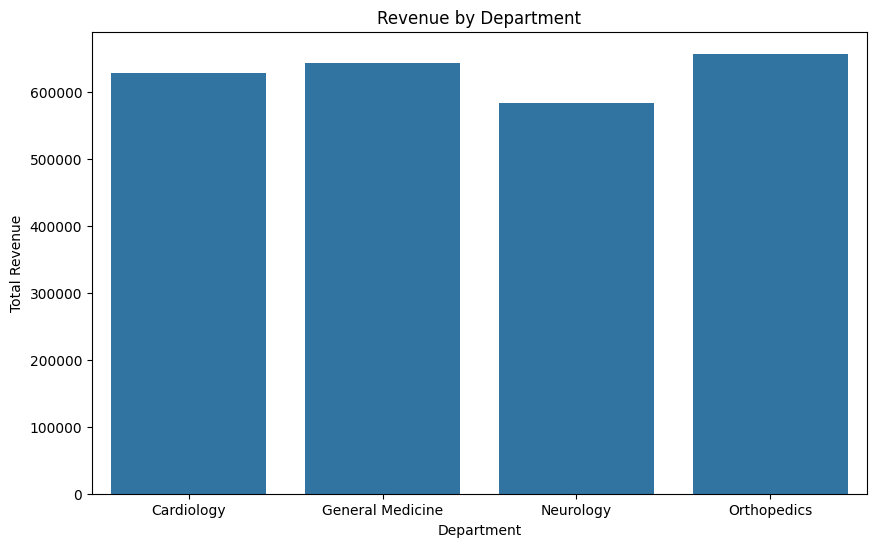

In [17]:
revenue_by_dept = df_hospital.groupby('Department')['Bill_Amount'].sum()
print('Revenue by department:')
print(revenue_by_dept)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_dept.index, y=revenue_by_dept.values)
plt.title('Revenue by Department')
plt.xlabel('Department')
plt.ylabel('Total Revenue')
plt.show()

### 2. What is the distribution of patient age and gender across departments? Visualize the results.

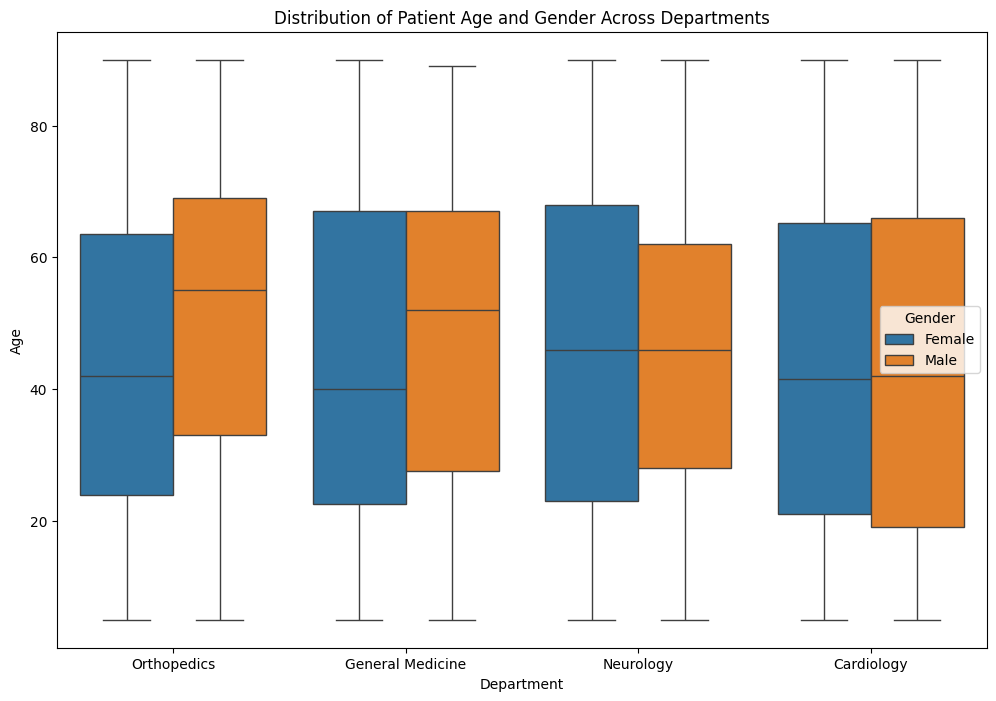

In [18]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Department', y='Age', hue='Gender', data=df_hospital)
plt.title('Distribution of Patient Age and Gender Across Departments')
plt.xlabel('Department')
plt.ylabel('Age')
plt.legend(title='Gender')
plt.show()

### 3. How do blood pressure levels vary across different age groups? Visualize the results.

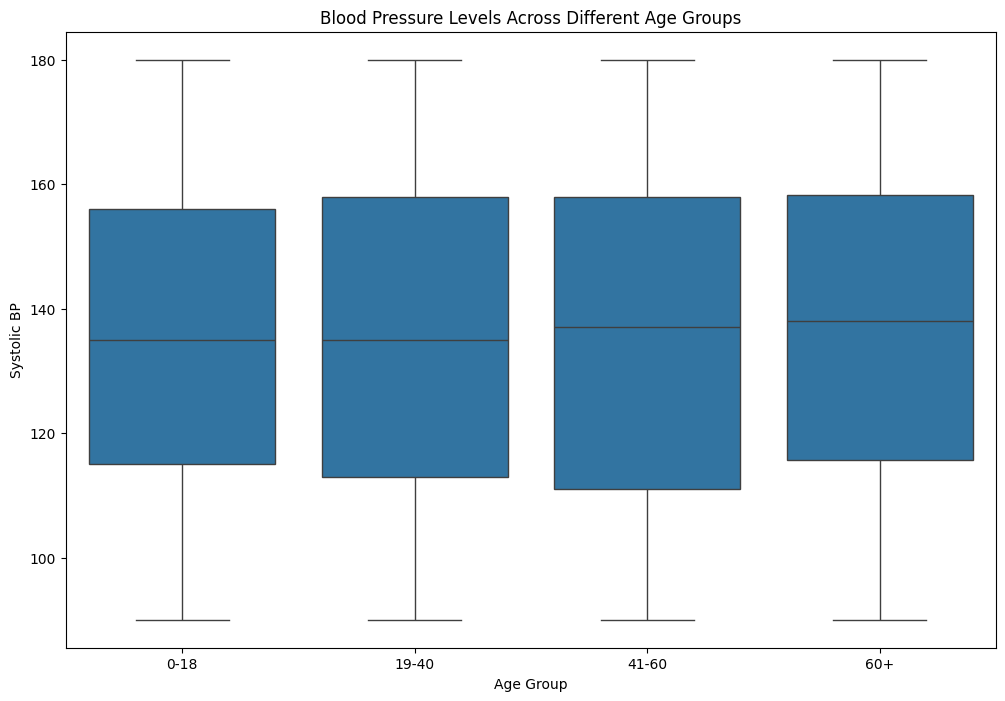

In [19]:
df_hospital['Age_Group'] = pd.cut(df_hospital['Age'], bins=[0, 18, 40, 60, 100], labels=['0-18', '19-40', '41-60', '60+'])
plt.figure(figsize=(12, 8))
sns.boxplot(x='Age_Group', y='Systolic_BP', data=df_hospital)
plt.title('Blood Pressure Levels Across Different Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Systolic BP')
plt.show()

### 4. What are the monthly visit and revenue trends in 2023? Visualize the results.

Monthly visit and revenue trends:
       Visits  Bill_Amount
Month                     
1          78       191049
2          77       195682
3          92       236838
4          89       226534
5          96       234373
6          82       206232
7          76       203478
8          80       200868
9          88       223238
10         75       175354
11         77       195200
12         90       222427


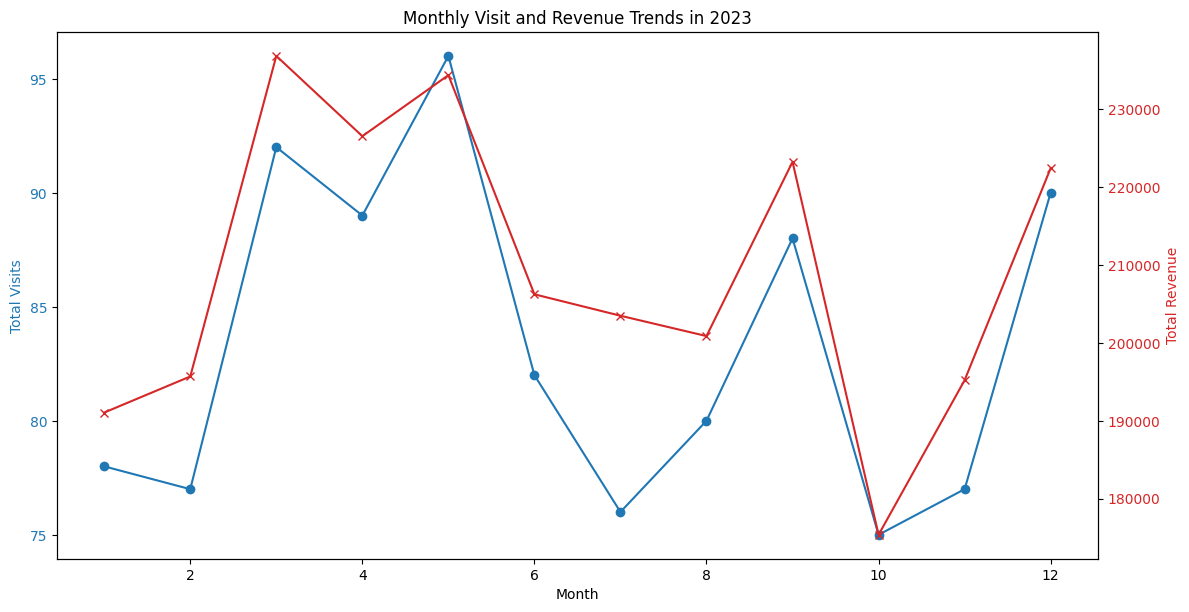

In [20]:
df_hospital['Month'] = df_hospital['Visit_Date'].dt.month
monthly_trends = df_hospital.groupby('Month').agg({'Patient_ID': 'count', 'Bill_Amount': 'sum'}).rename(columns={'Patient_ID': 'Visits'})
print('Monthly visit and revenue trends:')
print(monthly_trends)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Month')
ax1.set_ylabel('Total Visits', color='tab:blue')
ax1.plot(monthly_trends.index, monthly_trends['Visits'], color='tab:blue', marker='o', label='Visits')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Total Revenue', color='tab:red')
ax2.plot(monthly_trends.index, monthly_trends['Bill_Amount'], color='tab:red', marker='x', label='Revenue')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.title('Monthly Visit and Revenue Trends in 2023')
plt.show()